# Assignment 1: Linear Classifier

- **Name：？？？？？？？**

- **Student ID：？？？？？？？**


In this assignment, you will implement a linear classifier from scratch and evaluate it on the CIFAR-10 dataset for image classification.
You will experience **prompt programming** — writing a prompt for each code cell, using an AI tool to generate the corresponding code, and then pasting the generated code into the cell for execution.

---

## What is a Linear Classifier?

A linear classifier is the simplest image classification model. Its core idea is to flatten all pixels of an image into a vector, then apply a linear transformation (i.e., a fully connected layer) to map the high-dimensional vector to the class space, and finally obtain a probability distribution over classes through the softmax function.

Mathematically, a linear classifier can be expressed as:

$$f(\mathbf{x}) = \text{softmax}(W\mathbf{x} + \mathbf{b})$$

where:
- $\mathbf{x}$ is the flattened image vector with dimension $3072 = 32 \times 32 \times 3$
- $W$ is the weight matrix with dimension $10 \times 3072$
- $\mathbf{b}$ is the bias vector with dimension $10$
- The output is a 10-dimensional probability vector, where each component represents the probability of the input image belonging to the corresponding class

---

## Learning Objectives

1. Understand the basic principles of linear classifiers
2. Implement a linear classifier using the PyTorch framework
3. Train and evaluate the model on the CIFAR-10 dataset
4. Understand what the model has learned through weight visualization
5. Experience the prompt programming workflow


---

# 1. Environment Setup


## 1.1 Import Basic Libraries

> **Prompt**
>
> Import the fundamental libraries needed for this assignment:
> 1. Import `matplotlib.pyplot` and `matplotlib`
> 2. Import `numpy` and `time`
> 3. Import `seaborn` for enhanced visualization
> 4. From `sklearn.metrics`, import `confusion_matrix`, `classification_report`, `precision_recall_fscore_support`, and `accuracy_score`


In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import time
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support, accuracy_score

## 1.2 Download and Explore the CIFAR-10 Dataset

> **Prompt**
>
> Use the PyTorch framework to download and load the CIFAR-10 dataset, and perform initial data exploration. Follow these steps:
>
> **1. Import the required libraries:**
> - `torch`, `torch.nn`, `torchvision.transforms`, `torchvision.datasets`
> - `torch.utils.data.DataLoader`
>
> **2. Configure dataset parameters:**
> - Set the dataset download path to `'./data'`
> - Set `batch_size = 32`
>
> **3. Define data preprocessing:**
> - Use `transforms.Compose` to combine `ToTensor()` and `Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])`
> - The Normalize transform scales pixel values from [0,1] to [-1,1]
>
> **4. Download and load the training and test sets:**
> - Use `torchvision.datasets.CIFAR10` with `download=True`
> - Training set: `train=True`, test set: `train=False`
> - Create corresponding DataLoader instances: training set with `shuffle=True`, test set with `shuffle=False`, `num_workers=2`
>
> **5. Define the 10 class names of CIFAR-10:**
> - `classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')`
>
> **6. Visualize sample images:**
> - Take one batch from the training set and display the first 4 images with their labels in a 2x2 subplot grid
> - When displaying, reverse the normalization (`img / 2 + 0.5`) and convert the channel dimension from CHW to HWC (using `np.transpose`)
> - Use `np.clip()` to ensure pixel values are in [0, 1] range before displaying
>
> **7. Print basic dataset information:**
> - Training set size, test set size, image dimensions (e.g., `[3, 32, 32]`)


100.0%


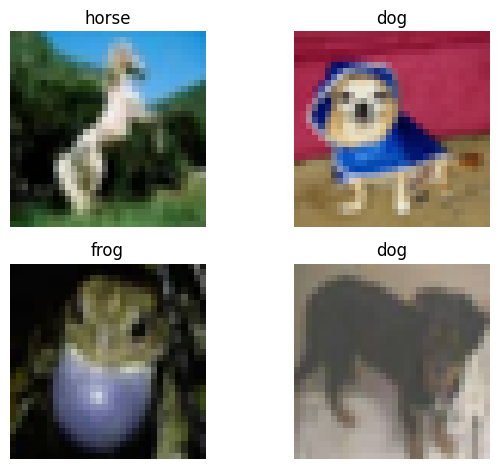

horse dog   frog  dog  
Training set size: 50000
Test set size: 10000
Image dimensions: torch.Size([3, 32, 32])


In [3]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader

# Dataset download path and batch size
data_path = './data'
batch_size = 32

# Define data transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Download and load the training set
trainset = datasets.CIFAR10(
    root=data_path,
    train=True,
    transform=transform,
    download=True)

trainloader = DataLoader(
    trainset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2)

# Download and load the test set
testset = datasets.CIFAR10(
    root=data_path,
    train=False,
    transform=transform,
    download=True)

testloader = DataLoader(
    testset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2)

# CIFAR-10 class names
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# Get a batch of training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Create image grid
fig, axes = plt.subplots(2, 2)
for i in range(4):
    row, col = i // 2, i % 2
    img = images[i]
    # Preprocess for display
    img = img / 2 + 0.5  # Reverse normalization
    npimg = img.numpy()
    npimg = np.transpose(npimg, (1, 2, 0))  # CHW -> HWC
    npimg = np.clip(npimg, 0, 1)  # Ensure valid pixel range
    
    axes[row, col].imshow(npimg)
    axes[row, col].set_title(classes[labels[i].item()])
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

# Print label information
print(' '.join(f'{classes[labels[j].item()]:5s}' for j in range(4)))

# Print dataset information
print(f'Training set size: {len(trainset)}')
print(f'Test set size: {len(testset)}')
print(f'Image dimensions: {trainset[0][0].shape}')

---

# 2. Linear Classifier Design


## 2.1 Set Random Seeds and Detect Computing Device

> **Prompt**
>
> Set random seeds to ensure reproducible results, and detect the available computing device. Write code to:
> 1. Use `torch.manual_seed(42)` and `np.random.seed(42)` to set random seeds
> 2. Use `torch.cuda.is_available()` to check if a GPU is available
> 3. Set `device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')` and print the device being used (e.g., `cuda` or `cpu`)


In [ ]:
# TODO: add your code here

Using device: cuda


## 2.2 Define the Linear Classifier Model

> **Prompt**
>
> Define a linear classifier class `LinearClassifier` using PyTorch, inheriting from `nn.Module`. Specific requirements:
>
> 1. In the `__init__` method, define a fully connected layer `self.fc = nn.Linear(3072, 10)` that maps 3072-dimensional input to 10-dimensional output
> 2. In the `forward` method:
>    - First, use `torch.flatten(x, 1)` to flatten the input (keeping the batch dimension, flattening all other dimensions)
>    - Then pass through the fully connected layer `self.fc(x)` to get the linear output (logits)
>    - Finally, use `torch.softmax(x, dim=1)` to convert the output into a probability distribution
> 3. Note: PyTorch's softmax uses the `dim` parameter (not `axis`)


In [ ]:
# TODO: add your code here

## 2.3 Instantiate the Model and Inspect Its Structure

> **Prompt**
>
> Instantiate the `LinearClassifier` model, move it to the computing device detected earlier using `.to(device)`, and then print the model structure to confirm the parameters are correct.


In [6]:
# Instantiate the model
model = LinearClassifier().to(device)
print(model)

LinearClassifier(
  (fc): Linear(in_features=3072, out_features=10, bias=True)
)


---

# 3. Model Training


## 3.1 Define the Loss Function and Optimizer

> **Prompt**
>
> Define the loss function and optimizer needed for model training:
> 1. Loss function: Use `nn.CrossEntropyLoss()` (cross-entropy loss)
> 2. Optimizer: Use `torch.optim.Adam`, passing `model.parameters()` as the parameters to optimize, with a learning rate of `0.01`


In [7]:
# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()  # Cross-entropy loss
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)  # Adam optimizer, learning rate 0.01

## 3.2 Write the Training Function

> **Prompt**
>
> Write a model training function `train_model(epochs=20)`. Specific requirements:
>
> 1. Initialize two empty lists `train_losses` and `train_accs` to record the loss and accuracy for each epoch
> 2. Record the training start time
> 3. In each epoch, iterate over the training data `trainloader`:
>    - Get input data `inputs` and labels `labels`; move them to `device`
>    - Execute the standard training step: **zero gradients** -> **forward pass** -> **compute loss** -> **backward pass** -> **optimizer step**
>    - Accumulate the loss value and the number of correct predictions
>    - Use `torch.argmax(outputs, dim=1)` to get the predicted class
>    - Print current loss and cumulative accuracy every 500 batches
> 4. At the end of each epoch, compute and record the epoch's loss and accuracy
> 5. After training completes, print the total elapsed time
> 6. The function returns `train_losses` and `train_accs` lists


In [ ]:
# TODO: add your code here

## 3.3 Execute Training

> **Prompt**
>
> Call the `train_model` function with `epochs=20` to start training, and save the return values as `train_losses` and `train_accs`.


In [9]:
# Train the model
train_losses, train_accs = train_model(epochs=20)

Training started...
[Epoch 1, Batch 100] Loss: 2.258, Accuracy: 19.78%
[Epoch 1, Batch 600] Loss: 11.054, Accuracy: 23.98%
[Epoch 1, Batch 1100] Loss: 10.926, Accuracy: 25.55%
Epoch 1 completed. Training Accuracy: 26.28%
[Epoch 2, Batch 100] Loss: 2.185, Accuracy: 27.53%
[Epoch 2, Batch 600] Loss: 10.864, Accuracy: 28.54%
[Epoch 2, Batch 1100] Loss: 10.798, Accuracy: 29.24%
Epoch 2 completed. Training Accuracy: 29.77%
[Epoch 3, Batch 100] Loss: 2.154, Accuracy: 30.72%
[Epoch 3, Batch 600] Loss: 10.745, Accuracy: 31.06%
[Epoch 3, Batch 1100] Loss: 10.762, Accuracy: 30.93%
Epoch 3 completed. Training Accuracy: 31.17%
[Epoch 4, Batch 100] Loss: 2.125, Accuracy: 33.59%
[Epoch 4, Batch 600] Loss: 10.674, Accuracy: 32.74%
[Epoch 4, Batch 1100] Loss: 10.707, Accuracy: 32.36%
Epoch 4 completed. Training Accuracy: 32.50%
[Epoch 5, Batch 100] Loss: 2.120, Accuracy: 34.09%
[Epoch 5, Batch 600] Loss: 10.702, Accuracy: 32.35%
[Epoch 5, Batch 1100] Loss: 10.674, Accuracy: 32.46%
Epoch 5 completed. T

## 3.4 Visualize the Training Process

> **Prompt**
>
> Plot the loss and accuracy curves during training. Create a 1x2 subplot layout (`figsize=(12, 5)`):
> - **Left subplot**: Plot `train_losses`, title "Training Loss", x-axis label "Epoch", y-axis label "Loss"
> - **Right subplot**: Plot `train_accs`, title "Training Accuracy", x-axis label "Epoch", y-axis label "Accuracy (%)"
> - Use `plt.tight_layout()` to automatically adjust subplot spacing


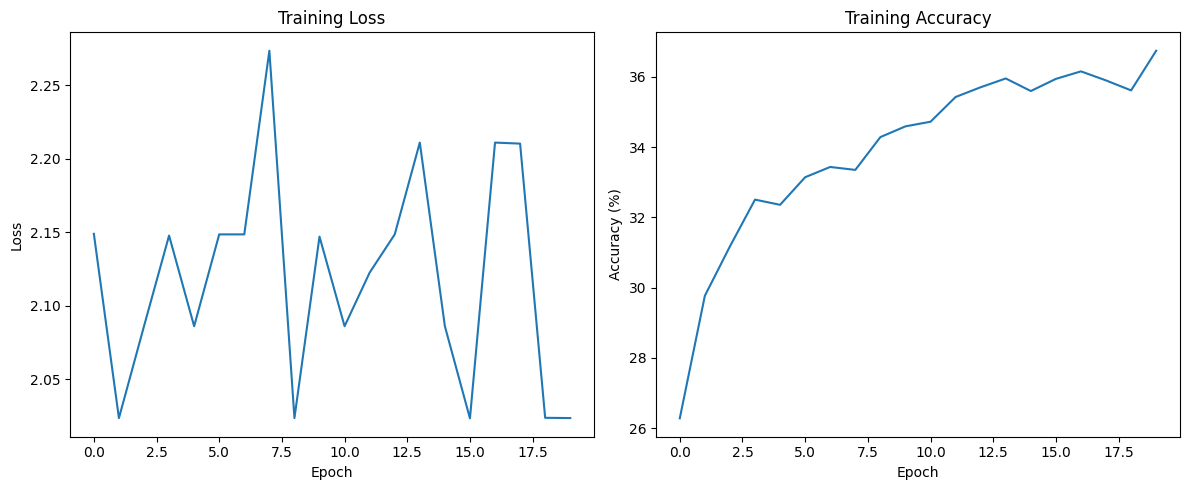

In [10]:
# Plot training loss and accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.plot(train_accs)
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')

plt.tight_layout()
plt.show()

---

# 4. Model Testing and Evaluation


## 4.1 Write the Evaluation Function

> **Prompt**
>
> Write a model evaluation function `evaluate_model()` to comprehensively assess model performance on the CIFAR-10 test set. Specific requirements:
>
> **1. Inference phase:**
> - Set the model to evaluation mode with `model.eval()`
> - Use `torch.no_grad()` context manager, iterate over `testloader`, and collect all predictions and ground truth labels
> - Move inputs and labels to `device` before inference
>
> **2. Compute evaluation metrics:**
> - Overall accuracy: use `accuracy_score`
> - Per-class accuracy: compute separately for each class by filtering samples
> - Confusion matrix: `confusion_matrix`
> - Precision, Recall, F1-score: `precision_recall_fscore_support(average=None)`
> - Full classification report: `classification_report(target_names=classes)`
>
> **3. Visualizations (3 plots in total):**
> - **Confusion matrix heatmap** (10x8): use `sns.heatmap` with `annot=True, fmt='d', cmap='Blues'`, x-axis "Predicted Label", y-axis "True Label"
> - **Precision/Recall/F1 bar chart** (12x6): display three metrics side by side (`width=0.25`), x-axis as class names (rotated 45 degrees), add legend
> - **Per-class accuracy bar chart** (10x6): x-axis as class names (rotated 45 degrees), y-axis as accuracy percentage
>
> **4. Return value:** `accuracy, class_accuracies, cm, precision, recall, f1`


In [ ]:
# TODO: add your code here

## 4.2 Execute Evaluation

> **Prompt**
>
> Call the `evaluate_model()` function to evaluate the model on the test set, and save the return value as `test_accuracy`.


Overall Accuracy: 36.71%
Class plane: 44.20%
Class car: 40.10%
Class bird: 0.00%
Class cat: 11.00%
Class deer: 45.90%
Class dog: 36.20%
Class frog: 47.70%
Class horse: 37.80%
Class ship: 54.60%
Class truck: 49.60%

Classification Report:
              precision    recall  f1-score   support

       plane       0.47      0.44      0.46      1000
         car       0.46      0.40      0.43      1000
        bird       0.00      0.00      0.00      1000
         cat       0.21      0.11      0.14      1000
        deer       0.29      0.46      0.36      1000
         dog       0.36      0.36      0.36      1000
        frog       0.32      0.48      0.38      1000
       horse       0.34      0.38      0.36      1000
        ship       0.44      0.55      0.49      1000
       truck       0.40      0.50      0.44      1000

    accuracy                           0.37     10000
   macro avg       0.33      0.37      0.34     10000
weighted avg       0.33      0.37      0.34     10000



d:\ProgramData\Miniconda3\envs\torch_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\ProgramData\Miniconda3\envs\torch_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\ProgramData\Miniconda3\envs\torch_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

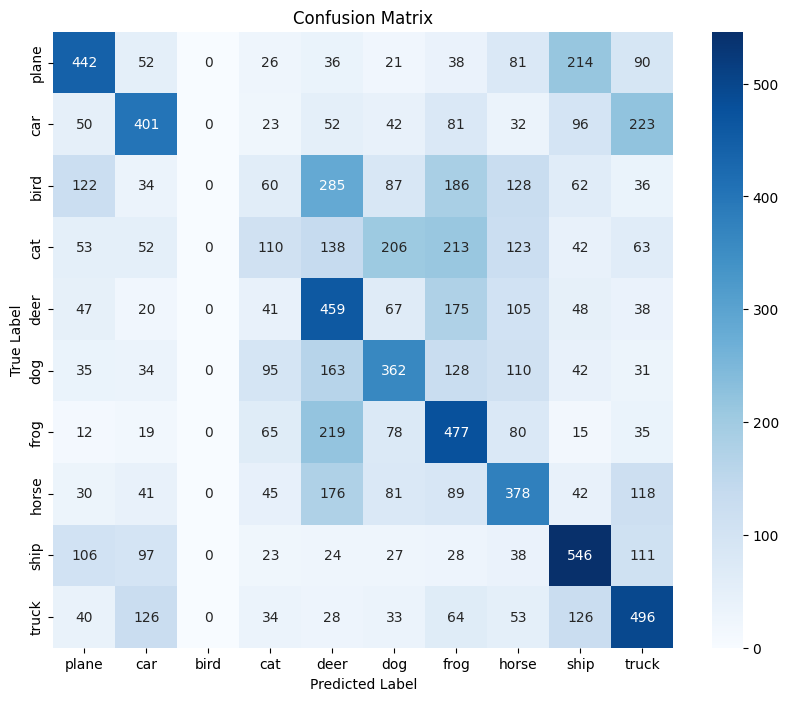

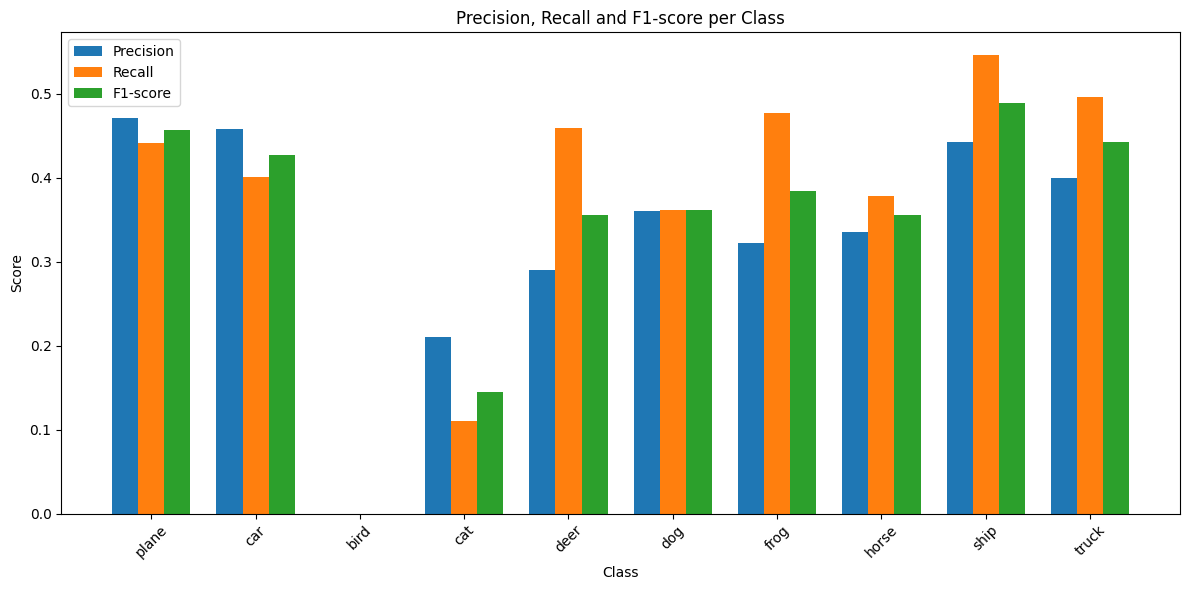

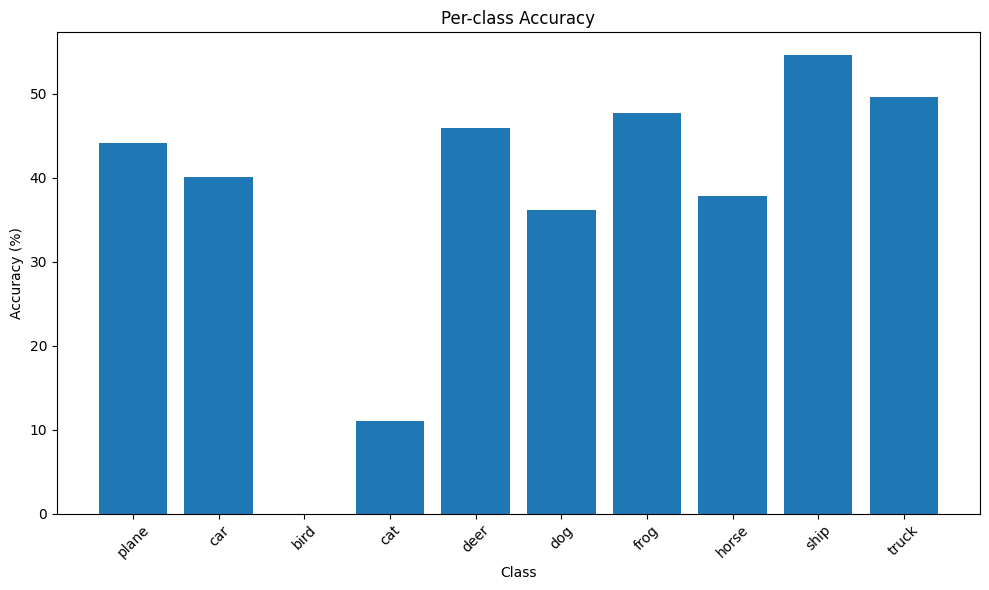

In [12]:
# Evaluate the model
test_accuracy = evaluate_model()

---

# 5. Weight Visualization

Each row of the weight matrix $W$ in the linear classifier corresponds to a "template" for one class. By reshaping the weights back to image dimensions, we can intuitively see what pattern each output neuron is "looking for".


## 5.1 Write the Weight Visualization Function

> **Prompt**
>
> Write a weight visualization function `visualize_weights()` that visualizes the weights of each output neuron in the linear classifier as image templates. Follow these steps:
>
> 1. Get the weights: `model.fc.weight.data.cpu().numpy()` (shape will be `[10, 3072]`)
> 2. Reshape the weights to `[10, 3, 32, 32]`, i.e., each class corresponds to a 32x32 3-channel image
> 3. Create a 2x5 subplot layout (`figsize=(15, 8)`)
> 4. For each class weight image:
>    - Use `np.transpose(weights[i], (1, 2, 0))` to convert channel dimension from CHW to HWC
>    - Use min-max normalization to map values to [0, 1] range: `(img - img.min()) / (img.max() - img.min())`
>    - Display using `imshow`, set the title to the corresponding class name, and turn off the axis
> 5. Use `tight_layout()` to adjust the layout


In [ ]:
# TODO: add your code here

## 5.2 Execute Weight Visualization

> **Prompt**
>
> Call the `visualize_weights()` function to display the weight templates of each output neuron in the linear classifier.


Original weight shape: (10, 3072)


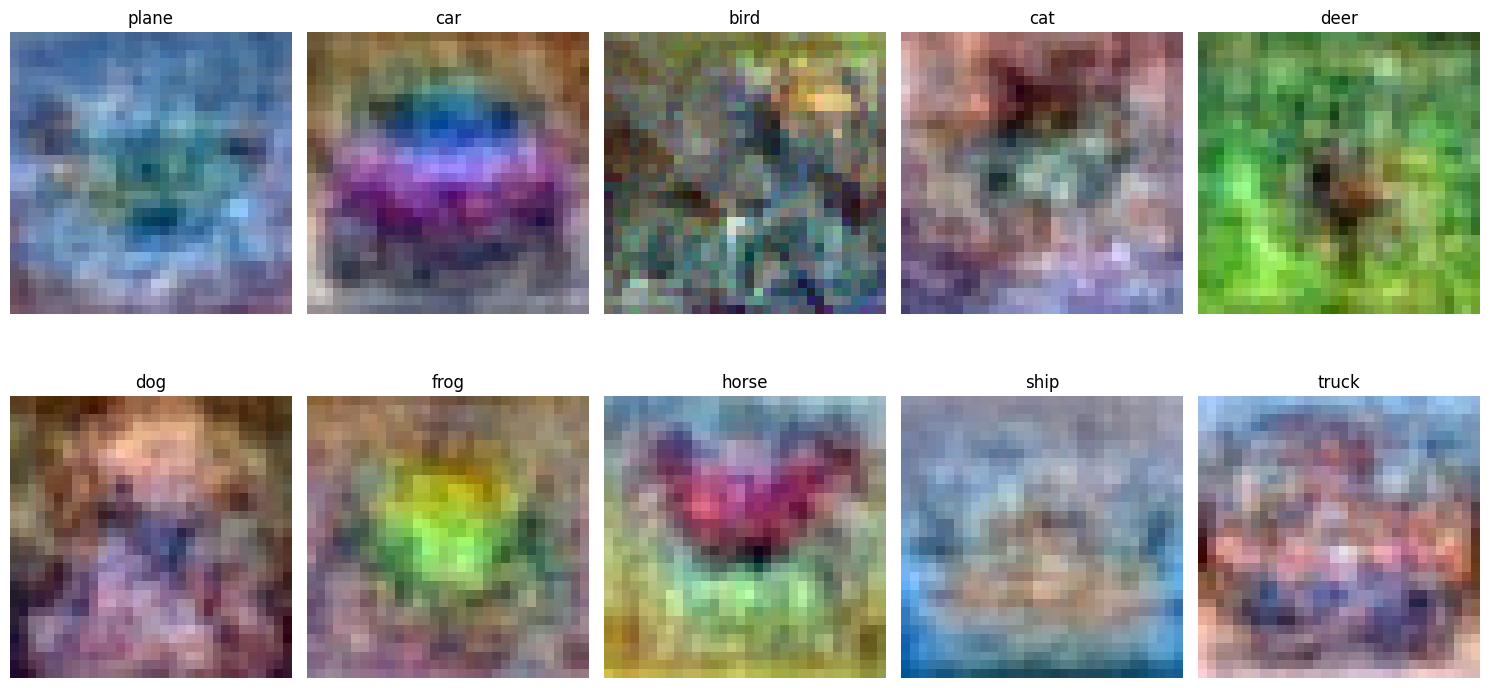

In [14]:
# Visualize weights
visualize_weights()

---

# 6. Summary and Reflection

After completing the experiments above, please reflect on the following questions:

1. **Classification Performance Analysis**: What is the approximate accuracy of the linear classifier on CIFAR-10? Is this result satisfactory? From the perspective of model capacity, why is the performance of a linear classifier limited?

2. **Training Curve Analysis**: Observe the training loss and accuracy curves. Does the model exhibit overfitting or underfitting? Has the training converged?

3. **Confusion Pattern Analysis**: From the confusion matrix, which classes are most easily confused? Can these confusions be explained from the perspective of image features?

4. **Weight Visualization Interpretation**: What patterns can you observe in the weight template images? What are the similarities and differences between the weight templates of different classes? Why do some class weight templates appear more "sharp" while others appear more "blurry"?

5. **Improvement Directions**: If you wanted to improve classification performance, what approaches would you consider? (Hint: feature extraction, nonlinear transformations, data augmentation, deeper network architectures, etc.)
